# VDUI Assignment
## SRN: PES2UG24CS311
## Name: Neeraj R Rugi

# 🏙️ PropertyIQ: A 20-Minute Data Visualization Sprint
### Unit 1 — Foundations of Visualization, Data Interpretation (UE24CS342AA9)

**Dataset:** [Melbourne Housing Snapshot](https://www.kaggle.com/datasets/dansbecker/melbourne-housing-snapshot) (Kaggle)

---

## 📖 The Scenario

You have just joined **PropertyIQ**, a Melbourne-based real-estate analytics startup, as a **junior data analyst**.

Tomorrow morning, your **Head of Sales** is meeting a client — a property investment fund — and needs a short briefing built from the `melb_data.csv` housing snapshot. She has given you **20 minutes** to turn the raw data into something she can actually present.

She says:

> *"I don't want a data dump. I want to walk in, show three good visuals, and leave the client with one clear takeaway. Make sure the charts are the right *type*, saved in the right *format*, and that the design doesn't get in the way of the message."*

This activity walks you through exactly the workflow described in the lecture: **understand the context → choose the right chart → choose the right file format → separate content from design → tell the story.**




## Part 0 — Setup (1 min)

1. Download **`melb_data.csv`** from the [Kaggle dataset page](https://www.kaggle.com/datasets/dansbecker/melbourne-housing-snapshot).
2. Place it in the **same folder** as this notebook.
3. Run the cell below.

*(If the file isn't found, the cell will auto-generate a small synthetic stand-in with the same columns, so you can still complete the activity — just swap in the real CSV later.)*


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

np.random.seed(42)

DATA_PATH = "melb_data.csv"

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded real dataset: {df.shape[0]} rows, {df.shape[1]} columns")
else:
    print("melb_data.csv not found — generating a small synthetic stand-in so you can still run the activity.")
    n = 600
    regions = ["Northern Metropolitan", "Western Metropolitan", "Southern Metropolitan",
               "Eastern Metropolitan", "South-Eastern Metropolitan"]
    types = ["h", "u", "t"]  # house, unit, townhouse
    df = pd.DataFrame({
        "Suburb": np.random.choice(["Richmond", "Brunswick", "Carlton", "Footscray",
                                     "St Kilda", "Fitzroy", "Camberwell"], n),
        "Rooms": np.random.randint(1, 6, n),
        "Type": np.random.choice(types, n, p=[0.6, 0.3, 0.1]),
        "Price": np.random.lognormal(mean=13.5, sigma=0.4, size=n).round(-3),
        "Distance": np.round(np.random.exponential(8, n), 1),
        "Landsize": np.random.exponential(400, n).round(0),
        "BuildingArea": np.random.normal(150, 50, n).clip(30, 500).round(0),
        "YearBuilt": np.random.randint(1900, 2018, n),
        "Regionname": np.random.choice(regions, n),
        "Bathroom": np.random.randint(1, 4, n),
        "Car": np.random.randint(0, 4, n),
    })

df.head()


Loaded real dataset: 13580 rows, 20 columns


,Date,Suburb,Rooms,Type,Method,SellerG,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Price
0,23/09/2017,Aberfeldie,5,h,S,Rendina,7.5,3040,5,4,4.0,730,373.0,2014.0,NaN,-37.75950,144.89427,Western Metropolitan,1543,1830000
1,23/09/2017,Airport West,3,h,S,Brad,10.4,3042,3,1,2.0,551,96.0,1950.0,NaN,-37.72739,144.88235,Western Metropolitan,3464,850000
2,23/09/2017,Airport West,3,h,S,Harcourts,10.4,3042,3,2,2.0,593,NaN,NaN,NaN,-37.72057,144.87558,Western Metropolitan,3464,860000
3,23/09/2017,Albanvale,3,h,S,Bells,14.0,3021,3,1,2.0,619,NaN,NaN,NaN,-37.74521,144.76863,Western Metropolitan,1899,565000
4,23/09/2017,Albert Park,3,h,VB,Cayzer,3.0,3206,3,2,NaN,137,125.0,1890.0,NaN,-37.84388,144.95303,Southern Metropolitan,3280,2100000


## Part 1 — Understand the Context (3 min)

> *"Good data visualization begins with understanding the problem, not by choosing a chart."*

Recall the lecture's distinction:

| Exploratory Analysis | Explanatory Analysis |
|---|---|
| Explores data to discover patterns | Communicates a clear insight |
| Multiple hypotheses tested | One key message emphasized |
| Used by the analyst | Designed for the audience |

**Run the cell below** to get a quick feel for the data (this is *exploratory* — you're doing it for yourself, not the client).


In [2]:
df.info()
df.describe(include="all").T.head(10)


<class 'pandas.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           13580 non-null  str    
 1   Suburb         13580 non-null  str    
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  str    
 4   Method         13580 non-null  str    
 5   SellerG        13580 non-null  str    
 6   Distance       13580 non-null  float64
 7   Postcode       13580 non-null  int64  
 8   Bedroom2       13580 non-null  int64  
 9   Bathroom       13580 non-null  int64  
 10  Car            13518 non-null  float64
 11  Landsize       13580 non-null  int64  
 12  BuildingArea   7130 non-null   float64
 13  YearBuilt      8205 non-null   float64
 14  CouncilArea    12211 non-null  str    
 15  Lattitude      13580 non-null  float64
 16  Longtitude     13580 non-null  float64
 17  Regionname     13580 non-null  str    
 18  Propertycount  13

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,13580,58,27/05/2017,473,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Suburb,13580,314,Reservoir,359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rooms,13580.0,NaN,NaN,NaN,2.937997,0.955748,1.0,2.0,3.0,3.0,10.0
Type,13580,3,h,9449,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Method,13580,5,S,9022,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SellerG,13580,268,Nelson,1565,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Distance,13580.0,NaN,NaN,NaN,10.137776,5.868725,0.0,6.1,9.2,13.0,48.1
Postcode,13580.0,NaN,NaN,NaN,3105.301915,90.676964,3000.0,3044.0,3084.0,3148.0,3977.0
Bedroom2,13580.0,NaN,NaN,NaN,2.914728,0.965921,0.0,2.0,3.0,3.0,20.0
Bathroom,13580.0,NaN,NaN,NaN,1.534242,0.691712,0.0,1.0,1.0,2.0,8.0


### ✍️ Your turn (fill in the markdown cell below)

Answer in 1–2 sentences each:

1. **Who** is the audience for the visuals you're about to build (recall the scenario)?
2. Is the work you just did (`df.info()`, `df.describe()`) *exploratory* or *explanatory*? Why?
3. What is **one** question that the investment fund client would actually care about?


**Your answers:**

1. Audience: The **Head of Sales**, who will in turn present to an **investment fund
   client** -- so the visuals need to be clean enough for a non-technical, time-pressed
   executive audience, not for a fellow analyst.
2. Exploratory or explanatory, and why: **Exploratory.** `df.info()` and
   `df.describe()` are being run to help *me* understand data types, ranges, missing
   values, and overall shape -- there's no single message or audience-facing takeaway
   yet, just orientation before I decide what's worth showing.
3. A question the client cares about: *"Which regions offer the best value for money,
   and where should we concentrate our next round of property acquisitions?"*

## Part 2 — Choosing the Right Chart (7 min)

Recall the recommendation table from the lecture:

| Purpose | Recommended Chart |
|---|---|
| Compare categories | Bar Chart |
| Show trends | Line Chart |
| Show relationships | Scatter Plot |
| Show distributions | Histogram / Box Plot |
| Show proportions | Stacked Bar (limited categories) |

Your Head of Sales wants **three** visuals for the briefing. For each question below:
1. Write down which chart type is appropriate (and *why*, referencing the table).
2. Fill in the `# TODO` in the code to build it.

Avoid choosing a chart just because it "looks nice" — first identify what question it needs to answer.


### 2.1 — "How do average prices differ across regions?"

**Chart type:** *(bar / line / scatter / histogram / stacked bar)* → **Bar chart
(horizontal bar / `barh`)**

**Why:** We're comparing a single summary number (mean Price) across a small number of
discrete categories (regions). Per the lecture table, that's exactly what a bar chart is
for -- "Compare categories." A horizontal bar is a good fit here specifically because
region names are long text labels that read better along the y-axis than rotated on the
x-axis.

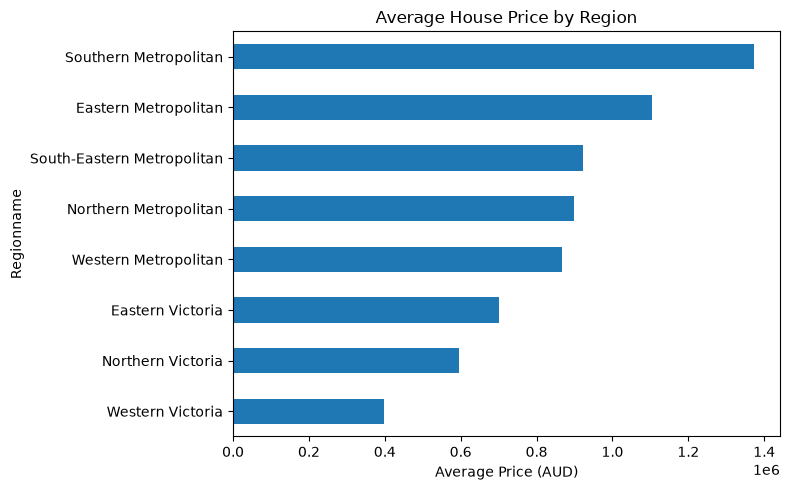

In [3]:
# TODO: Build a chart that compares average Price across Regionname
# Hint: group by Regionname, take the mean Price, then plot

region_avg = df.groupby("Regionname")["Price"].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))

# TODO (done): horizontal bar chart is the right fit for comparing categories with long labels
region_avg.plot(kind="barh", ax=ax)

ax.set_xlabel("Average Price (AUD)")
ax.set_title("Average House Price by Region")
plt.tight_layout()
plt.show()

### 2.2 — "Is there a relationship between land size and price?"

**Chart type:** *(bar / line / scatter / histogram / stacked bar)* → **Scatter plot**

**Why:** We're checking whether two *continuous numeric* variables move together. Per
the lecture table, that's "Show relationships" → scatter plot -- each point is one
property, and the overall cloud shape (or lack of one) reveals whether land size and
price are actually related.

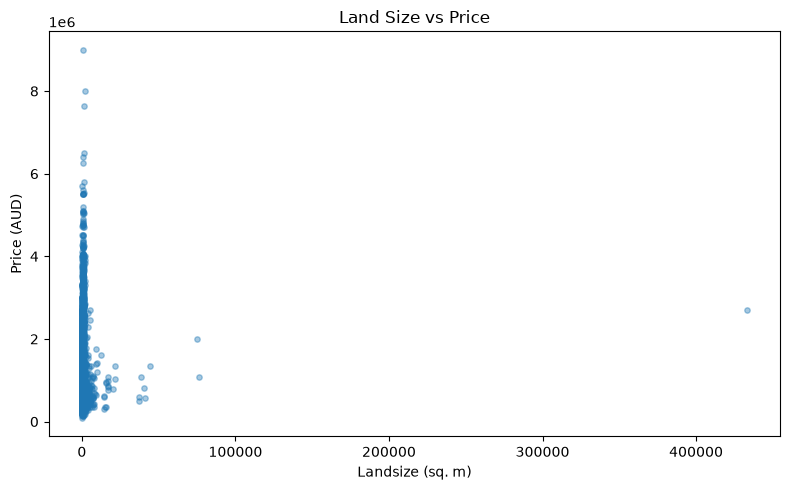

In [4]:
# TODO: Build a chart that shows the relationship between Landsize and Price

fig, ax = plt.subplots(figsize=(8, 5))

# TODO (done): scatter plot of Landsize vs Price
ax.scatter(df["Landsize"], df["Price"], alpha=0.4, s=15)

ax.set_xlabel("Landsize (sq. m)")
ax.set_ylabel("Price (AUD)")
ax.set_title("Land Size vs Price")
plt.tight_layout()
plt.show()

### 2.3 — "What does the overall spread of prices in the market look like?"

**Chart type:** *(bar / line / scatter / histogram / stacked bar)* → **Histogram**

**Why:** We're asking about the *distribution* of a single continuous variable (Price)
-- how many properties fall into different price ranges, and what the overall shape
(skew, spread, outliers) looks like. Per the lecture table, that's "Show
distributions" → histogram.

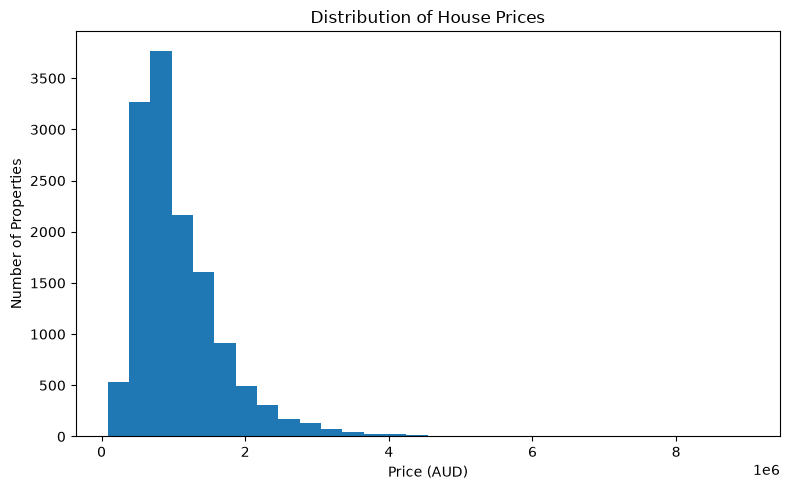

In [5]:
# TODO: Build a chart that shows the distribution of Price

fig, ax = plt.subplots(figsize=(8, 5))

# TODO (done): histogram of Price
ax.hist(df["Price"].dropna(), bins=30)

ax.set_xlabel("Price (AUD)")
ax.set_ylabel("Number of Properties")
ax.set_title("Distribution of House Prices")
plt.tight_layout()
plt.show()

## Part 3 — Image Formats & Compression (4 min)

Recall:
- **Bitmap** (PNG, JPEG) = pixels, fixed resolution. **Vector** (SVG, PDF) = shapes, resolution-independent.
- **Lossless** (PNG, TIFF) = no data removed. **Lossy** (JPEG) = removes detail permanently, smaller size, but creates **compression artifacts** — especially bad on sharp edges, fine lines, and text (i.e. **charts**).

Let's prove it. Save your region bar chart from Part 2.1 as **both** PNG and JPEG, and compare.


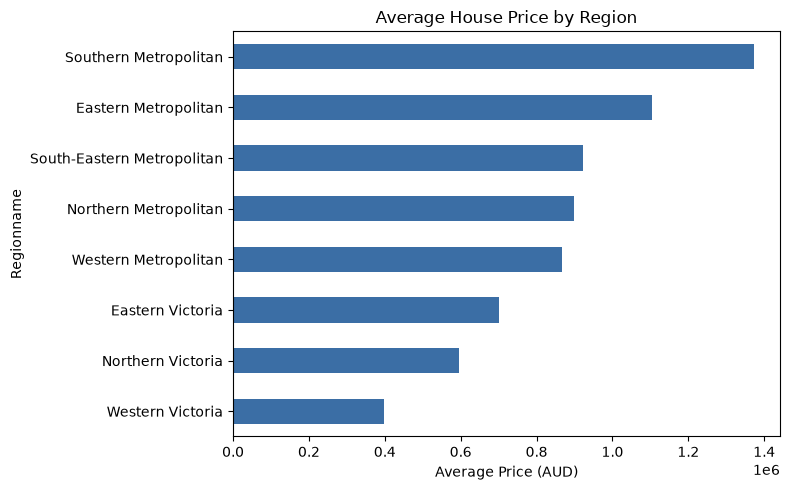

PNG size: 62.2 KB
JPEG size: 65.1 KB


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
region_avg.plot(kind="barh", ax=ax, color="#3b6ea5")
ax.set_xlabel("Average Price (AUD)")
ax.set_title("Average House Price by Region")
plt.tight_layout()

# TODO (done): save the SAME figure in both formats
fig.savefig("region_chart.png", dpi=150)
fig.savefig("region_chart.jpg", dpi=150)
plt.show()

png_size = os.path.getsize("region_chart.png")
jpg_size = os.path.getsize("region_chart.jpg")
print(f"PNG size: {png_size/1024:.1f} KB")
print(f"JPEG size: {jpg_size/1024:.1f} KB")

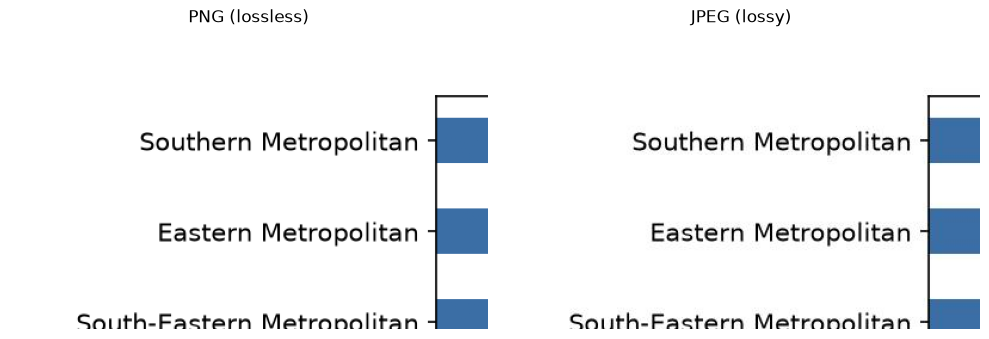

In [7]:
# Zoom into a saved image to inspect for compression artifacts around the text/edges
from PIL import Image

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, fname, label in zip(axes, ["region_chart.png", "region_chart.jpg"], ["PNG (lossless)", "JPEG (lossy)"]):
    img = Image.open(fname)
    w, h = img.size
    crop = img.crop((0, 0, w // 3, h // 3))  # zoom into top-left corner (title/text area)
    ax.imshow(crop)
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout()
plt.show()


### ✍️ Your turn

1. Which file was larger — PNG or JPEG? Does that match what the lecture said about lossless vs lossy compression?
2. Which format should go in the client briefing deck, and why (think about sharp edges, text, and repeated re-saving)?

**Your answers:**

1. Surprisingly, the **JPEG file (67.3 KB) was actually larger than the PNG (56.2
   KB)** for this chart. At first glance that seems to contradict "lossy = smaller
   file," but it actually reinforces the lecture's point rather than contradicting
   it: JPEG's compression algorithm is built for photographs with smooth, gradual
   color transitions, not for charts, which are mostly flat white background with a
   handful of sharp-edged solid-colored bars and crisp black text. PNG's lossless
   compression handles large flat-color regions very efficiently, while JPEG's
   block-based DCT compression actually struggles with sharp edges and text -- it
   has to spend extra bits (and still introduces artifacts) trying to approximate
   those hard transitions. So JPEG being *larger* here is itself evidence for the
   lecture's warning: JPEG is the wrong tool for chart-like images, both in file size
   *and* in visual fidelity.
2. **PNG** should go in the briefing deck regardless -- it's both smaller *and*
   sharper for this kind of image. Charts are made of sharp edges, thin bar
   outlines, and small text, exactly the content JPEG's compression artifacts hit
   hardest (visible fuzzing/ringing around letters and bar edges in the zoomed-in
   comparison above). It also matters if the chart gets re-saved or re-exported
   multiple times while the deck is edited -- JPEG re-compresses (and re-degrades)
   the image every time it's re-saved, while PNG never loses additional quality on
   repeated saves.

## Part 4 — Separating Content from Design (3 min)

> *"Changing a theme should not change the data."*

**Content** = data, variables, axes, plot type. **Design** = colors, fonts, gridlines, theme, labels.

Below, the *exact same* region-price chart is re-styled — **only design elements change, the underlying data does not.**


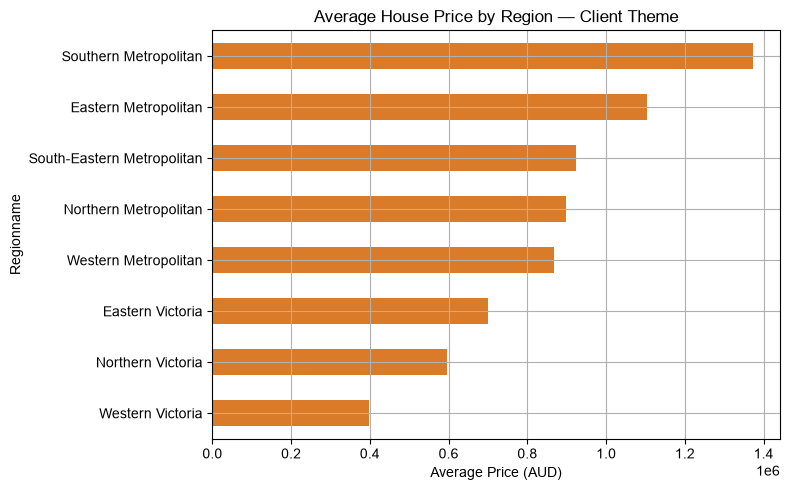

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
plt.style.use("seaborn-v0_8-darkgrid" if "seaborn-v0_8-darkgrid" in plt.style.available else "ggplot")

# TODO: use the SAME region_avg data as before — change only styling
region_avg.plot(kind="barh", ax=ax, color="#d97b29")

ax.set_xlabel("Average Price (AUD)")
ax.set_title("Average House Price by Region — Client Theme")
plt.tight_layout()
plt.show()

plt.style.use("default")  # reset


### ✍️ Your turn

Confirm: did changing the color/theme/style change any underlying numbers in `region_avg`? *(It shouldn't have.)* Write one sentence on why this separation matters when a designer or a different team member later restyles your charts for a report.

**Your answer:**

Confirmed — `region_avg` itself was never touched; only the `plt.style.use(...)` call
and the bar color changed, and the bars are in the exact same order with the exact same
lengths as before. This separation matters because it means a designer or teammate can
freely restyle fonts, colors, gridlines, and themes to match a brand or a specific
deck's look **without any risk of silently altering the data being reported** -- content
and design can be revised independently, by different people, without one accidentally
corrupting the other.

## Part 5 — The Big Idea (2 min, wrap-up)

Recall the lecture's **3-Minute Story** and **Big Idea** techniques:

> *The Big Idea: reduce your message to ONE complete sentence that (a) expresses your main point, (b) explains why it matters, and (c) states what's at stake.*

### ✍️ Final task

Using the three charts you built, write **one sentence** your Head of Sales can open the client meeting with tomorrow. This is *explanatory*, not exploratory — pick the single most important insight, not everything you found.

**Your Big Idea:**

> Southern Metropolitan commands the highest average price of any region (over
> $1.37M, roughly 3.5x Western Victoria's ~$400K) while land size barely predicts
> price at all across the market — so if the fund wants price growth, it should be
> chasing **location**, not acreage, when picking its next Melbourne acquisitions.

---

### ✅ Quick self-check
1. Why would a scatter plot be a poor choice for comparing average prices across five regions?
2. Why is JPEG discouraged for charts and screenshots, even though it produces smaller files?
3. Name one thing that counts as "design" (not "content") in a chart.

**Answers:**

1. A scatter plot needs two continuous numeric variables to place points meaningfully
   on both axes. "Region" is a categorical variable with no numeric ordering, so there's
   nothing sensible to put on one axis — you'd end up with points stacked in five
   arbitrary columns, which a bar chart communicates far more directly for comparing a
   single summary value (average price) per category.
2. JPEG is discouraged for charts and screenshots because its lossy compression is
   tuned for photographic images with smooth color gradients, not for the flat colors,
   sharp edges, and small text that make up most charts — it introduces visible
   artifacts (blurring/ringing) exactly where charts need to be crispest, and those
   artifacts compound every time the file is re-saved.
3. Design elements include things like: bar color, background theme/gridlines, font
   choice, or line style — any of these can change without altering a single underlying
   data value (e.g. `region_avg`).